In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Four MLP's

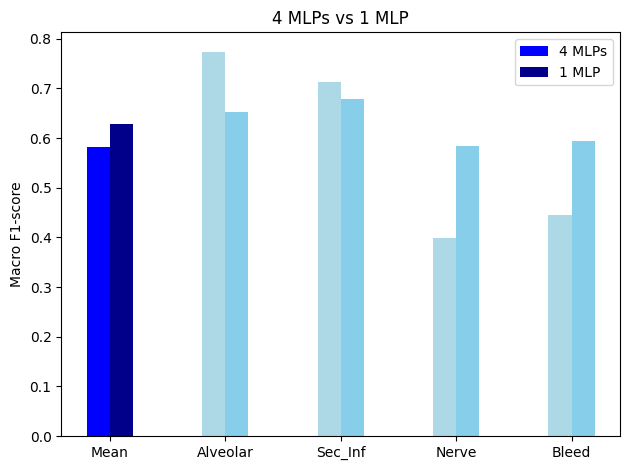

In [11]:
four_MLP = [0.7743, 0.7124, 0.3986, 0.4450]
one_MLP = [0.6521, 0.6795, 0.5848, 0.5935]


# Data
four_MLP_ = [sum(four_MLP)/4] + four_MLP
one_MLP_ = [sum(one_MLP)/4] + one_MLP


# Kategorier (ret navnene hvis du har bedre labels)
categories = ['Mean', 'Alveolar', 'Sec_Inf', 'Nerve', 'Bleed']

# Positioner på x-aksen
x = np.arange(len(categories))
width = 0.2


colors_four = ['blue',] + ['lightblue'] * (len(categories) - 1)
colors_one = ['darkblue'] + ['skyblue'] * (len(categories) - 1)

# Plot
plt.figure()
plt.bar(x - width/2, four_MLP_, width, label='4 MLPs', color = colors_four)
plt.bar(x + width/2, one_MLP_, width, label='1 MLP', color = colors_one)

# Labels og layout
plt.xticks(x, categories)
plt.ylabel('Macro F1-score')
plt.title('4 MLPs vs 1 MLP')
plt.legend()

plt.tight_layout()
plt.show()

Vi ser i ovenstående, at der er større varians på tværs af komplikationer i performance for de fire MLP'er. Performance er meget dårlig for de sjældne kategorier, 'Nerve' og 'Bleeding'. Dette formoder vi er fordi, at de sjældne komplikation har for få positive cases til, at modellen kan nå at lære det ordentligt. Derfor er det en fordel, at have en samlet model, som kan lære de generelle features, som er relevante på tværs af komplikationer fx, 'nerve_proximity'. \
Ud fra dette ***konkluderer vi***, at 4 individuelle MLP'er klarer sig dårligt, og ikke er en god arkitektur

## 1 model uden branching, men forskellige størrelser

/var/folders/5b/ygpdcsbn6x9cn8vd1y60fzjw0000gn/T/ipykernel_57413/1686771123.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


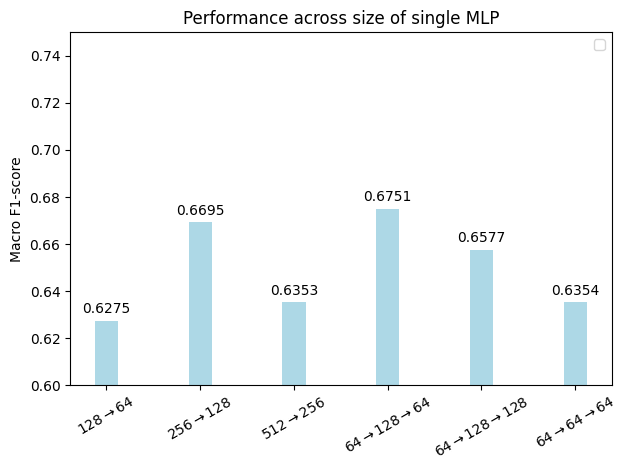

In [4]:
# data
_64_128 = np.mean([0.6521, 0.6795, 0.5848, 0.5935])
_256_128 = np.mean([0.7735, 0.6593, 0.6563, 0.5889])
_512_256 = np.mean([0.63, 0.6703, 0.6617, 0.5792])
_64_128_64 = np.mean([0.7275, 0.7107, 0.6361, 0.6261])
_64_128_128 = np.mean([0.7200, 0.6874, 0.6362, 0.5870])
_64_64_64 = np.mean([0.7230, 0.6698, 0.5790, 0.5697])


data = [_64_128, _256_128, _512_256, _64_128_64, _64_128_128, _64_64_64]

# Kategorier (ret navnene hvis du har bedre labels)
categories = ['128$\\rightarrow$64', '256$\\rightarrow$128' ,'512$\\rightarrow$256', 
              '64$\\rightarrow$128$\\rightarrow$64','64$\\rightarrow$128$\\rightarrow$128',
              '64$\\rightarrow$64$\\rightarrow$64']

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots()


bars = ax.bar(x, data, width, color='lightblue')

# Tilføj F1-score ovenpå hver bar
ax.bar_label(bars, fmt='%.4f', padding=3)

# Labels og layout
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation = 30)
ax.set_ylim(0.6, 0.75)
ax.set_ylabel('Macro F1-score')
ax.set_title('Performance across size of single MLP')
ax.legend()

plt.tight_layout()
plt.show()


## Modeller med branching. Shared lag er for alle 128 $\rightarrow$ 64

/var/folders/5b/ygpdcsbn6x9cn8vd1y60fzjw0000gn/T/ipykernel_57413/866394280.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


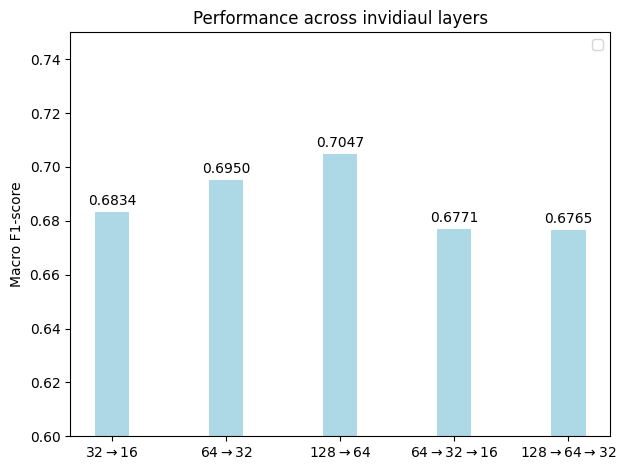

In [5]:
# data
layer_2_2_32_16 = np.mean([0.7573, 0.6977, 0.6272, 0.6513])
layer_2_2_64_32 = np.mean([0.7571, 0.7393, 0.6433, 0.6404])
layer_2_2_128_64 = np.mean([0.7715, 0.7367, 0.6957, 0.6148])
layer_2_3_64_32_16 = np.mean([0.7285, 0.6874, 0.6220, 0.6703])
layer_2_3_128_64_32 = np.mean([0.7258, 0.6929, 0.6457, 0.6415])

data = [layer_2_2_32_16, layer_2_2_64_32, layer_2_2_128_64, layer_2_3_64_32_16, layer_2_3_128_64_32 ]

# Kategorier
categories = ['32$\\rightarrow$16', '64$\\rightarrow$32' ,'128$\\rightarrow$64', '64$\\rightarrow$32$\\rightarrow$16', '128$\\rightarrow$64$\\rightarrow$32']

x = np.arange(len(categories))
width = 0.3

fig, ax = plt.subplots()

bars = ax.bar(x, data, width, color='lightblue')

# tilføj 
ax.bar_label(bars, fmt='%.4f', padding=3)

# labels 
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0.6, 0.75)
ax.set_ylabel('Macro F1-score')
ax.set_title('Performance across invidiaul layers')
ax.legend()

plt.tight_layout()
plt.show()


## Single MLP, four MLP and branching MLP

/var/folders/5b/ygpdcsbn6x9cn8vd1y60fzjw0000gn/T/ipykernel_57413/2037627841.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


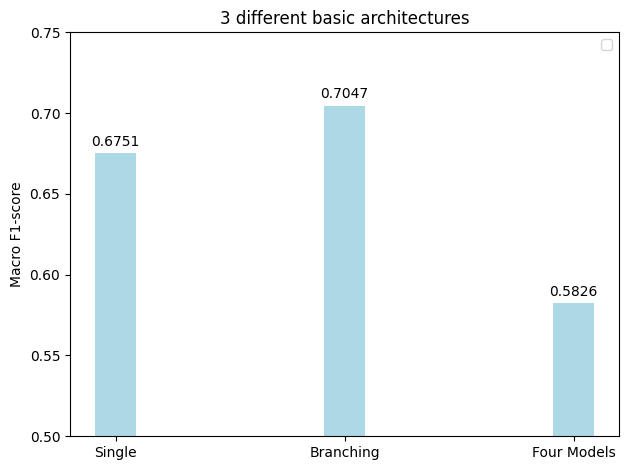

In [6]:
# data
single = np.mean([0.7275, 0.7107, 0.6361, 0.6261])
four = np.mean([0.7743, 0.7124, 0.3986, 0.4450])
branching = layer_2_2_128_64 = np.mean([0.7715, 0.7367, 0.6957, 0.6148])

data = [single, branching, four]

# Kategorier (ret navnene hvis du har bedre labels)
categories = ['Single', 'Branching', 'Four Models']

x = np.arange(len(categories))
width = 0.18

fig, ax = plt.subplots()

bars = ax.bar(x, data, width, color='lightblue')

# Tilføj F1-score ovenpå hver bar
ax.bar_label(bars, fmt='%.4f', padding=3)

# Labels og layout
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0.5, 0.75)
ax.set_ylabel('Macro F1-score')
ax.set_title('3 different basic architectures')
ax.legend()

plt.tight_layout()
plt.show()
